<a href="https://colab.research.google.com/github/Pramod-kumar-dev/StudentsPerformance/blob/main/Studentperfomance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student performance


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
from google.colab import files
uploaded = files.upload()

Saving StudentsPerformance.csv to StudentsPerformance (1).csv


In [12]:
# Explore the dataset:display shape, column names, data types and missing values
df = pd.read_csv('StudentsPerformance.csv')
print(df.head())
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.isnull().sum())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
(1000, 8)
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'w

In [13]:
subject_columns = ['math score', 'reading score', 'writing score']

print("Mean scores:")
print(df[subject_columns].mean())

print("\nStandard deviation of scores:")
print(df[subject_columns].std())

print("\nMedian (50th percentile) scores:")
print(df[subject_columns].quantile(0.5))

Mean scores:
math score       66.089
reading score    69.169
writing score    68.054
dtype: float64

Standard deviation of scores:
math score       15.163080
reading score    14.600192
writing score    15.195657
dtype: float64

Median (50th percentile) scores:
math score       66.0
reading score    70.0
writing score    69.0
Name: 0.5, dtype: float64


In [14]:
# use pandas groupby() to compare average scores by gender and parental education level.
print(df.groupby('gender')[subject_columns].mean())
print(df.groupby('parental level of education')[subject_columns].mean)

        math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203
<bound method GroupBy.mean of <pandas.core.groupby.generic.DataFrameGroupBy object at 0x7da81dd34350>>


In [15]:
# use pandas pd.cut() to categorize students into grade baands (A,B,C,D,F)

df['average_score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)
score_bins =   [0,59,69,79,89,100]
grade_labels = ['F', 'D', 'C', 'B', 'A']

# 3. Use pd.cut() to bin the scores into the specified grade bands
df['grade'] = pd.cut(df['average_score'], bins=score_bins, labels=grade_labels, include_lowest=True)

# Look at the breakdown of grades to verify
print("Grade Distribution:")
print(df['grade'].value_counts().sort_index(ascending=False))
print("\nFirst 5 rows with new grades:")
print(df[['math score', 'reading score', 'writing score', 'average_score', 'grade']].head())

Grade Distribution:
grade
A     58
B    156
C    260
D    252
F    274
Name: count, dtype: int64

First 5 rows with new grades:
   math score  reading score  writing score  average_score grade
0          72             72             74      72.666667     C
1          69             90             88      82.333333     B
2          90             95             93      92.666667     A
3          47             57             44      49.333333     F
4          76             78             75      76.333333     C


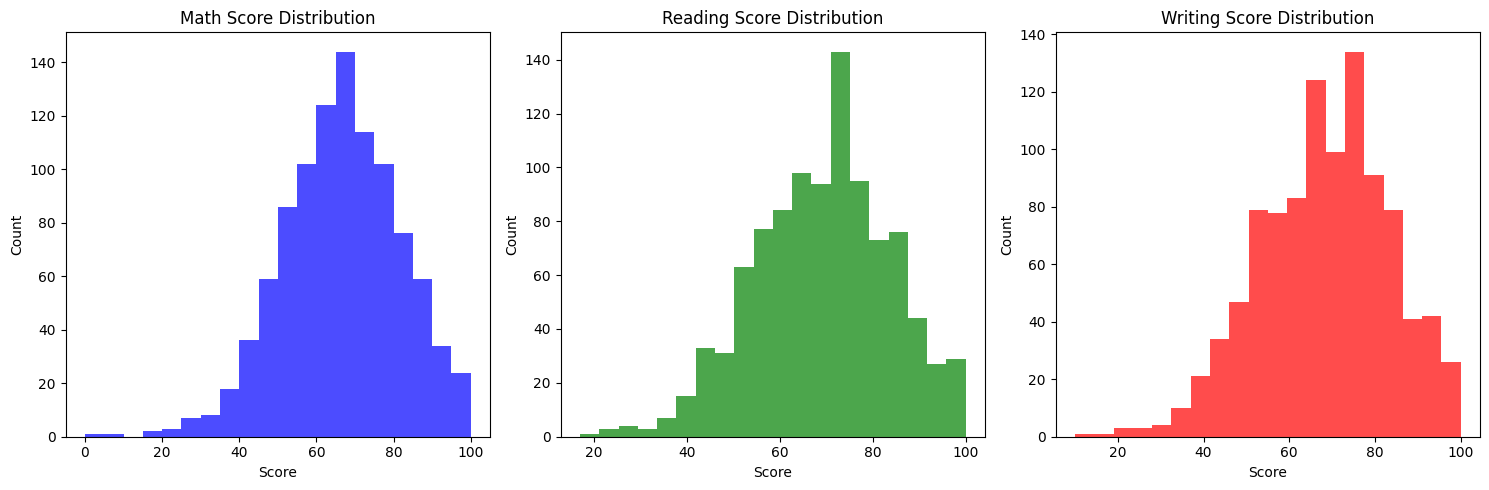

In [16]:
# plot a histogram of math , reading and writing scores using matplotlib(3 subplots)
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].hist(df['math score'], bins=20, color='blue', alpha=0.7)
axes[0].set_title('Math Score Distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')

axes[1].hist(df['reading score'], bins=20, color='green', alpha=0.7)
axes[1].set_title('Reading Score Distribution')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Count')

axes[2].hist(df['writing score'], bins=20, color='red', alpha=0.7)
axes[2].set_title('Writing Score Distribution')
axes[2].set_xlabel('Score')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

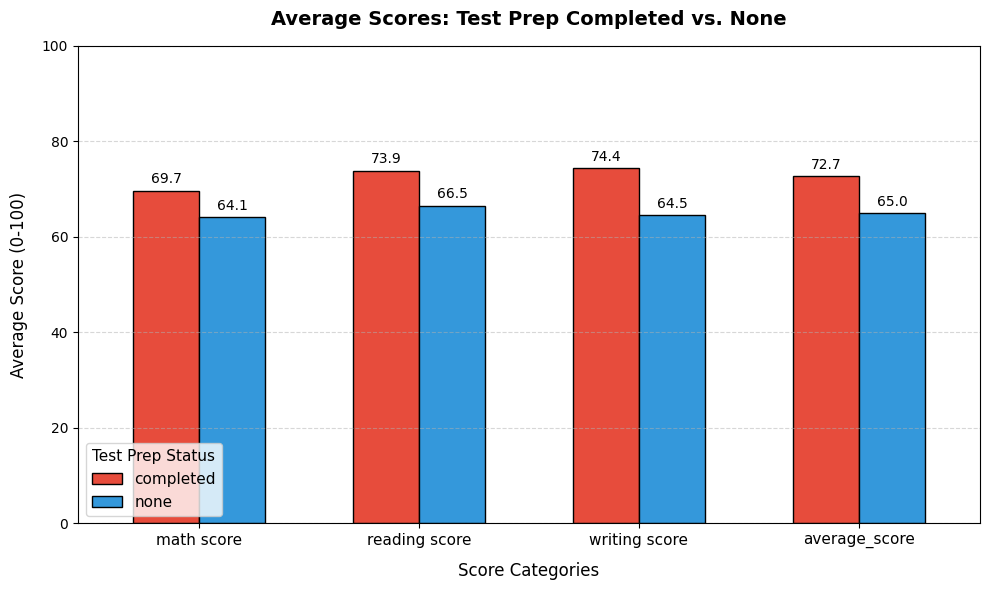

In [17]:
# create a plot chart comparing average scores of students who did vs did not complete test prep.

if 'average_score' not in df.columns:
    df['average_score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

prep_comparison = df.groupby('test preparation course')[['math score', 'reading score', 'writing score', 'average_score']].mean()

ax = prep_comparison.T.plot(kind='bar', figsize=(10, 6), color=['#e74c3c', '#3498db'], edgecolor='black', width=0.6)

plt.title('Average Scores: Test Prep Completed vs. None', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Score Categories', fontsize=12, labelpad=10)
plt.ylabel('Average Score (0-100)', fontsize=12, labelpad=10)
plt.xticks(rotation=0, fontsize=11)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)

plt.legend(title='Test Prep Status', fontsize=11, title_fontsize=11, loc='lower left')
plt.tight_layout()
plt.show()

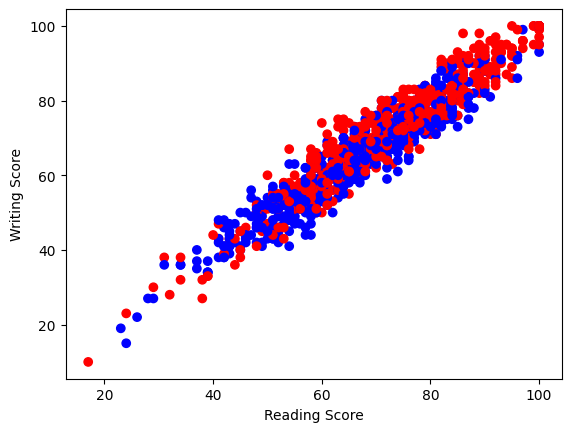

In [18]:
# Draw a scatter plot of reading score vs. writing score , colored by gender
plt.scatter(df['reading score'], df['writing score'], c=df['gender'].map({'male': 'blue', 'female': 'red'}))
plt.xlabel('Reading Score')
plt.ylabel('Writing Score')
plt.show()

In [19]:
# save all plots as png files and export the cleaned/processed dataFrame to a new CSV
plt.savefig('math_score_distribution.png')
plt.savefig('reading_score_distribution.png')
plt.savefig('writing_score_distribution.png')

<Figure size 640x480 with 0 Axes>